# Lab 2 Ghofran's code

In [16]:
#####################################
### Import the relevant libraries ###
#####################################
import random # to set random seed for reproducibility
# numpy and pandas: handle data and numerical operations.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # used for all the plots (accuracy/loss curves, confusion matrix, etc.)

from sklearn.model_selection import train_test_split # to split the dataset into training and testing sets
# converts text data into numerical vectors (TF-IDF = Term Frequency–Inverse Document Frequency)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler # rescales numbers between 0 and 1 (important for PGD and neural networks)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # to evaluate the model's performance
from sklearn.utils.class_weight import compute_class_weight # to handle class imbalance by assigning weights to classes
from sklearn.decomposition import PCA # to reduce dimensionality of TF-IDF vectors for visualization

# TensorFlow and Keras: import, build, and train the neural networks
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers # layers to build the neural network


In [17]:
# using a fixed seed ensures that random operations (train/test splits or sampling) produce the same results
# every time we run the notebook, making experiments repeatablem.
SEED = 4 # any integer works, 4 is arbitrary
np.random.seed(SEED) # set numpy random seed
tf.random.set_seed(SEED) # set TensorFlow random seed
random.seed(SEED) # set Python random seed

In [18]:
####################################
##### Load the cleaned dataset ##### 
####################################
DATA_PATH = "cleaned_medicheck-expert.csv" # path to the cleaned dataset
Dset = pd.read_csv(DATA_PATH) # loads cleaned dataset into a DataFrame.

print("Shape:", Dset.shape) # show the shape of the Dataset (rows, columns)
print(Dset.head(3)) # show the first 3 rows of the dataset

Shape: (1416, 2)
                                               query  query-label-expert
0  Why do i get a bad headache when i don't eat e...                   2
1  What causes heart rate to suddenly quicken to ...                   2
2  peritonsillar abscess drainage aftercare.. ple...                   2


In [19]:
##########################################
# Relabel to binary according to ANTONIO #
##########################################
# Antonio's relabeling scheme: 1,2,3 -> medical (0); 0 -> non-medical (1); else NaN 
def antonio_relabel(x):
    if x in [1, 2, 3]:   # any medical seriousness level
        return 0         # medical
    elif x == 0:
        return 1         # non-medical
    else:
        return np.nan

# Apply the relabeling function and clean the dataframe
# Keep only the relevant columns: "query" (text) and "query-label-expert" (label).
Dset = Dset[["query", "query-label-expert"]].copy() 
Dset["label"] = Dset["query-label-expert"].apply(antonio_relabel) # Apply the relabel function to create a new column "label".
Dset = Dset.dropna(subset=["label"]) # Drop rows where "label" is NaN (missing labels).
Dset["label"] = Dset["label"].astype(int) # Convert labels to integers (0 and 1).
# Clean the text:
    # astype(str) → ensure all entries are strings.
    # str.replace(r"\s+"," ", regex=True) → replace multiple spaces/tabs with a single space.
    # str.strip() → remove leading/trailing spaces.
Dset["query"] = Dset["query"].astype(str).str.replace(r"\s+"," ", regex=True).str.strip() 

# Shows how many 0s (medical) and 1s (non-medical) after relabelling.
print("Label distribution (ANTONIO):\n", Dset["label"].value_counts()) 
Dset.head(5) # show the first 5 rows of the updated dataset

Label distribution (ANTONIO):
 label
0    1412
1       4
Name: count, dtype: int64


,query,query-label-expert,label
0,Why do i get a bad headache when i don't eat e...,2,0
1,What causes heart rate to suddenly quicken to ...,2,0
2,peritonsillar abscess drainage aftercare.. ple...,2,0
3,How serious is Mono or tonsillitis when untrea...,2,0
4,What are your chances of dying in your sleep?,1,0


In [24]:
# Step 3D — Show a few examples from each class by picking 5 random queries from each class (0 and 1).
print("\nMedical (label 0) examples:")
for q in Dset[Dset.label==0].sample(min(5, (Dset.label==0).sum()), random_state=SEED)["query"].tolist():
    print(q)

print("\nNon-medical (label 1) examples:")
for q in Dset[Dset.label==1].sample(min(5, (Dset.label==1).sum()), random_state=SEED)["query"].tolist():
    print(q)


Medical (label 0) examples:
Friends five month old needs help!
What kind of doctor should I see? Back, Hip, Hip flexor, buttocks, and thigh pain.
Why does my left leg feel somewhat fine after I worked out?
If someone could please explain, what causes asthma?
What is the difference between nasal and temporal fields of vision?

Non-medical (label 1) examples:
If humans were not restrained by the obstetrical dilemma, how many weeks, on average, would a fetus take to naturally gestate inside the womb before birth, and and how large would it get?
Writer with a question: What kind of medical situations do you have to inform the police about?
How to responsibly take advantage of maxed deductible?
Reddit, I need your help making a decision.


In [25]:
############################################
###### Split data into train and test ######
############################################
X = Dset["query"].values  # X = all query texts.
y = Dset["label"].values  # y = corresponding binary labels (0=medical, 1=non-medical).

# train_test_split divides the dataset into:70% for training (X_train_text, y_train) 30% for testing (X_test_text, y_test)
X_train_text, X_test_text, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=SEED, stratify=y)  # stratify=y keeps the same label distribution in train and test sets

print("Train size:", len(X_train_text), " Test size:", len(X_test_text)) # show the sizes of train and test sets
print("Train label counts:", np.bincount(y_train))  # show the label distribution in the training set
print("Test  label counts:", np.bincount(y_test))   # show the label distribution in the test set

Train size: 991  Test size: 425
Train label counts: [988   3]
Test  label counts: [424   1]


In [26]:
######################################################################
# Turn text into numerical features >> Vectorizing the text (TF-IDF) #
######################################################################
# Step 3F — Vectorization (TF-IDF -> dense -> scaled to [0,1] for stable PGD)
# TF-IDF counts how important each word or word-pair (bigram) is for distinguishing between classes.
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000) # max_features keeps the top 5000 most frequent features
# Fit the vectorizer on training data and transform both train and test sets
X_train_tfidf = vectorizer.fit_transform(X_train_text)   # learn vocabulary from train data, then apply to training text
X_test_tfidf  = vectorizer.transform(X_test_text)   # apply the same train vocabulary to the test text.

# Converts sparse TF-IDF matrices into dense matrices for Keras + PGD (Keras expects dense inputs).
    # A dense array/matrix is a regular NumPy array where all values are stored explicitly in memory.
    # A sparse array only stores nonzero values and their positions, saving memory when most values are zero.
    # Machine learning libraries like Keras require dense arrays as input,
    # so sparse matrices (like those from TF-IDF vectorization) are converted to dense arrays before training.
X_train_dense = X_train_tfidf.toarray().astype("float32") 
X_test_dense  = X_test_tfidf.toarray().astype("float32")

# Scales each feature to the range [0, 1] for better numerical stability during training and adversarial attacks.
scaler = MinMaxScaler() # scales each feature to [0,1]
X_train = scaler.fit_transform(X_train_dense).astype("float32") # fit scaler on train, apply to train
X_test  = scaler.transform(X_test_dense).astype("float32")  # apply same scaler to test

X_train.shape, X_test.shape # check the shape of the final input matrices

((991, 5000), (425, 5000))

In [28]:
# Optional: compute class weights (helps if non-medical is rare)
# why? if dataset has far more medical (0) than non-medical (1) samples,
# the model could “cheat” by always predicting 0.
classes = np.unique(y_train) # find all unique label values in y_train (should be [0, 1])

# compute_class_weight: calculates a weight for each class so that rare classes are not ignored.
# class_weight="balanced": tells the function to balance the weights based on class frequencies.
# classes=classes: the list of unique class labels.
# y=y_train: the labels from the training set.
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

# This line creates a dictionary mapping each class label (int(c)) to its computed weight (float(w)).
# zip(classes, class_weights): pairs each class with its corresponding weight.
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict) # show the computed class weights

Class weights: {0: 0.5015182186234818, 1: 165.16666666666666}


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,769 (4.95 MB)

 Trainable params: 1,296,769 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9506 - loss: 1.0754 - val_accuracy: 1.0000 - val_loss: 0.2011
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9506 - loss: 1.0754 - val_accuracy: 1.0000 - val_loss: 0.2011
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9966 - loss: 0.8441 - val_accuracy: 1.0000 - val_loss: 0.1079
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9966 - loss: 0.8441 - val_accuracy: 1.0000 - val_loss: 0.1079
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9966 - loss: 0.5229 - val_accuracy: 1.0000 - val_loss: 0.0893
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9966 - loss: 0.5229 - val_accuracy: 1.0000 - val_loss: 0.0893
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9989 - loss: 0.3595 - val_accuracy: 1.0000 - val_loss: 0.0665
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9989 - loss: 0.3595 - val_accuracy: 1.0000 - v

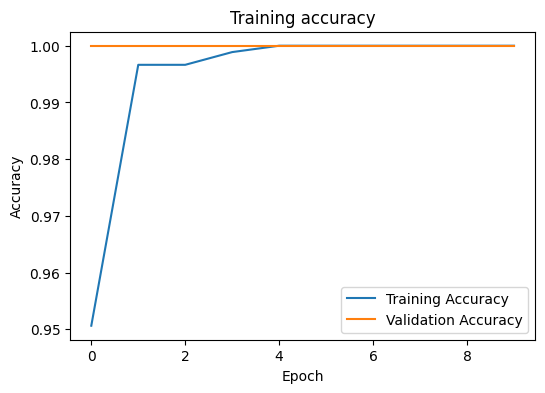

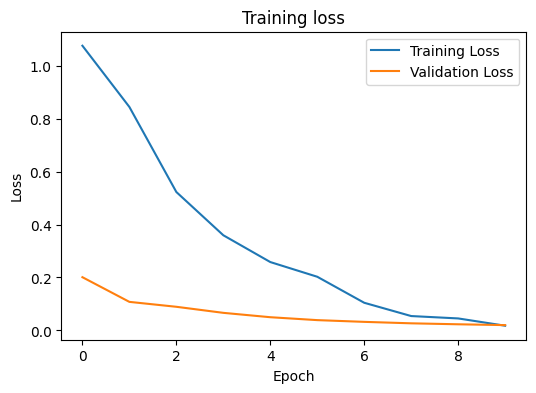

In [ ]:
###########################################
# Define and train a small dense NN model #
###########################################
def build_model(input_dim):
    model = keras.Sequential([          # Define a Sequential model (a stack of layers)
        layers.Input(shape=(input_dim,)),  # Input layer = size of TF-IDF vector
        layers.Dense(256, activation="relu"), # First fully connected hidden layer with 256 neurons and ReLU activation
        layers.Dropout(0.3),           # randomly ignores 30% of neurons during training (prevents overfitting)
        layers.Dense(64, activation="relu"), # Second fully connected hidden layer with 64 neurons and ReLU activation
        layers.Dense(1, activation="sigmoid") # Output layer = single neuron with sigmoid activation (binary classification)
    ])
    # Adam optimizer algorithm automatically adjusts learning rates during training,
    # making it efficient and popular for deep learning tasks.
    # 1e-3 = 0.001 sets the learning rate for the Adam optimizer,
    # controlling how much the model's weights are updated during training.
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",   # Loss function: binary cross-entropy (for binary classification)
                  metrics=["accuracy"])         # Metric to monitor: accuracy
    return model

model = build_model(X_train.shape[1])           # Build the model
model.summary()                                 # shows how many parameters each layer has


# Train baseline
history = model.fit(
    X_train,              # input features for training (dense, scaled TF-IDF vectors)
    y_train,              # target labels for training (0=medical, 1=non-medical)
    validation_split=0.1, # validation_split=0.1: use 10% of training data for validation (to monitor overfitting)
    epochs=10,            # epochs=10: train for 10 passes (go through the entire training dataset 10 times)
    batch_size=32,        # batch_size=32: number of samples processed before updating model weights
    verbose=1,            # verbose=1: print progress bar and training details during fitting
    # comment this if we don't want weighting:
    class_weight=class_weight_dict  # class_weight: dictionary of weights for each class (helps with class imbalance)
)


In [ ]:
########################
# Plot training curves #
########################
# Plot training accuracy
plt.figure(figsize=(6,4))                       # Create a new figure with size 6x4 inches
plt.plot(history.history["accuracy"], label="Training Accuracy")      # Plot training accuracy per epoch
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")    # Plot validation accuracy per epoch
plt.xlabel("Epoch")                              # Label x-axis as "Epoch"
plt.ylabel("Accuracy")                           # Label y-axis as "Accuracy"
plt.legend()                                     # Show legend for the curves
plt.title("Training accuracy")                   # Set plot title
plt.show()                                       # Display the plot

# Plotting training loss
plt.figure(figsize=(6,4))                        # Create a new figure for loss curves
plt.plot(history.history["loss"], label="Training Loss")          # Plot training loss per epoch
plt.plot(history.history["val_loss"], label="Validation Loss")        # Plot validation loss per epoch
plt.xlabel("Epoch")                              # Label x-axis as "Epoch"
plt.ylabel("Loss")                               # Label y-axis as "Loss"
plt.legend()                                     # Show legend for the curves
plt.title("Training loss")                       # Set plot title
plt.show()                                       # Display the plot

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Clean accuracy: 0.9976470588235294

Classification report:
               precision    recall  f1-score   support

           0      0.998     1.000     0.999       424
           1      0.000     0.000     0.000         1

    accuracy                          0.998       425
   macro avg      0.499     0.500     0.499       425
weighted avg      0.995     0.998     0.996       425



c:\Users\ghofr\Documents\GitHub\CDT-D2AIR-NLP\tfenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ghofr\Documents\GitHub\CDT-D2AIR-NLP\tfenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ghofr\Documents\GitHub\CDT-D2AIR-NLP\tfenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

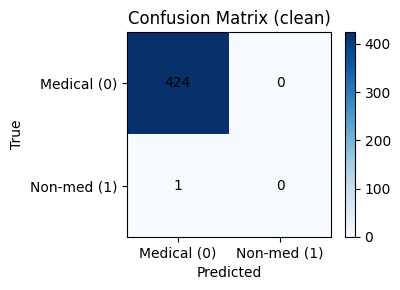

In [10]:
# Step 3H — Evaluation on clean test set
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Clean accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (clean)")
plt.colorbar()
plt.xticks([0,1], ["Medical (0)", "Non-med (1)"])
plt.yticks([0,1], ["Medical (0)", "Non-med (1)"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()


In [11]:
# Step 3I — Feature entanglement: hidden activations -> PCA 2D
# model up to the 64-unit layer
_ = model.predict(X_train[:1])  # build the model
feature_extractor = keras.Model(inputs=model.input, outputs=model.layers[-2].output)

# use a subset if data is large
X_all = np.vstack([X_train[:2000], X_test[:2000]])
y_all = np.concatenate([y_train[:2000], y_test[:2000]])

H = feature_extractor.predict(X_all, batch_size=256)
pca = PCA(n_components=2, random_state=SEED)
H2 = pca.fit_transform(H)

plt.figure(figsize=(6,5))
scatter = plt.scatter(H2[:,0], H2[:,1], c=y_all, alpha=0.6)
plt.title("Feature entanglement (PCA of hidden activations)")
plt.xlabel("PC1"); plt.ylabel("PC2")
cbar = plt.colorbar(scatter, ticks=[0,1]); cbar.ax.set_yticklabels(["Medical (0)","Non-med (1)"])
plt.tight_layout(); plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


AttributeError: The layer sequential has never been called and thus has no defined input.